# V31.19b — J90-DIRECT order-fixed certification + incremental benchmark
## Multi-optimizer finite-shot benchmark of Dicke circuit architectures

Este experimento isola a arquitetura do circuito.

Comparamos três objetos físicos/paramétricos diferentes:

$$
\boxed{\text{FULL}}
\qquad
\boxed{\text{REDUCED}}
\qquad
\boxed{\text{J90-DIRECT}}.
$$

A comparação é feita com os **mesmos otimizadores**, os mesmos Hamiltonianos, o mesmo teto de circuit-batches, o mesmo número de shots e streams pareados de ruído de medição.

---

## Arquitetura A — FULL

A construção nominal mantém todos os motifs:

$$
N_{\rm full}
=
kn-\frac{k(k+1)}2
=
k(n-k)+\binom{k}{2}.
$$

Os $\binom{k}{2}$ motifs estruturalmente mortos permanecem fisicamente no circuito e seus parâmetros continuam livres para o otimizador.

---

## Arquitetura B — REDUCED

Os motifs estruturalmente mortos nunca são construídos:

$$
\boxed{
N_{\rm reduced}=k(n-k).
}
$$

Esta é a redução estrutural exata identificada anteriormente.

---

## Arquitetura C — J90-DIRECT

O circuito possui a mesma topologia física do REDUCED, porém **já nasce** com apenas

$$
\boxed{
r_{90}
}
$$

parâmetros livres $q_a$.

A relação com os ângulos ativos é inserida diretamente nos gates:

$$
\Delta\phi_j
=
\sum_{a=1}^{r_{90}}
(Q_{90})_{ja}q_a,
$$

e

$$
\theta_j(q)
=
\theta_j^D
+
\frac{T_j}{2\pi}
\sum_{a=1}^{r_{90}}
(Q_{90})_{ja}q_a.
$$

Assim,

$$
\boxed{
U_{J90}(q)
=
U_{\rm reduced}
\left(
\phi_D+Q_{90}q
\right),
}
$$

mas a interface do circuito expõe apenas $r_{90}$ parâmetros.

Esta é uma compressão geométrica aproximada/local, e **não** uma remoção estrutural exata de gates.---

## Correção V31.19

O V31.18 reconstruiu o `J90_DIRECT` percorrendo `structure` em `theta_index`.
Isso pode reordenar motifs não comutantes.

Nesta versão:
- `circuit_order` é gravado explicitamente;
- $Q_{90}$ continua definido na base `theta_index`;
- o circuito físico é reconstruído em `circuit_order`;
- cada motif consulta a linha correta de $Q_{90}$ por `theta_index`;
- um hard gate exige
  $U_{J90}^{direct}(q)=U_{reduced}(Q_{90}q)$
  antes de qualquer benchmark.

FULL e REDUCED do V31.18 são reutilizados; somente J90 é recalibrado e rerodado.### V31.19b
O hard gate de topologia foi corrigido: igualdade literal de `qc.data`
não é exigida entre circuitos em níveis diferentes de decomposição.
A prova física permanece a equivalência statevector/TVD, e a arquitetura
é auditada na sequência ordenada de motifs.

# 1. Perguntas científicas

O benchmark foi organizado para responder separadamente:

### Q1 — Remoção estrutural

Para o mesmo otimizador,

$$
\boxed{
\text{REDUCED}
\stackrel{?}{\gtrless}
\text{FULL}.
}
$$

Isso testa se retirar os $\binom{k}{2}$ motifs mortos preserva ou melhora a otimização e reduz recursos de circuito.

### Q2 — Compressão geométrica

Para o mesmo otimizador,

$$
\boxed{
\text{J90-DIRECT}
\stackrel{?}{\gtrless}
\text{REDUCED}.
}
$$

Isso testa se restringir a busca às direções que concentram 90% do sinal Jacobiano melhora a eficiência finite-shot.

### Q3 — Dependência do otimizador

As duas comparações anteriores são repetidas com:

- COBYLA;
- CMA-ES;
- SPSA;
- Powell;
- Nelder–Mead.

Portanto não confundimos uma propriedade do circuito com uma peculiaridade de um único otimizador.

# 2. Protocolo finite-shot e justiça de orçamento

Não usamos energia exata, $P_{\rm ground}$ exato ou Hessiana exata para classificar os métodos.

O statevector é utilizado internamente apenas como **gerador de amostras de Born**, substituível por counts de hardware.

O protocolo padrão é

$$
B_{\rm total}=120\ {\rm circuit\ batches},
$$

$$
N_{\rm shots}=10\,000
$$

por batch.

Reservamos

$$
B_{\rm opt}=112
$$

para a busca e

$$
B_{\rm confirm}=8
$$

para uma confirmação independente do candidato final.

Cada run consome exatamente o mesmo teto físico. Se um algoritmo não consegue utilizar o último fragmento do orçamento, os batches restantes são medidos no candidato recomendado e registrados como `budget_padding`; eles **não alteram** a recomendação.

A confirmação final usa common random numbers entre braços do mesmo caso físico, reduzindo a variância das comparações pareadas.

# 3. Compilação robusta do $Q_{90}$

O subespaço $J90$ não é calculado a partir de uma única realização de shot.

Para cada $(n,k)$ produzimos múltiplas compilações independentes.

Para a seed $s$:

$$
G_{\rm cross}^{(s)}
=
\frac12
\left[
J_A^{(s)T}J_B^{(s)}
+
J_B^{(s)T}J_A^{(s)}
\right].
$$

Depois usamos

$$
\boxed{
\bar G_{\rm cross}
=
\frac1S
\sum_{s=1}^{S}
G_{\rm cross}^{(s)}.
}
$$

Projetamos $\bar G_{\rm cross}$ no cone PSD e definimos

$$
\frac{
\sum_{i=1}^{r_{90}}\lambda_i
}{
\sum_i\lambda_i
}
\ge 0.90.
$$

Também registramos:

- distribuição de $r_{90}^{(s)}$;
- overlap entre cada projetor e o projetor final;
- ângulo principal máximo.

Assim o circuito J90-DIRECT não depende de uma única flutuação de shot.

In [1]:
# ============================================================
# 0. Imports / configuration
# ============================================================
from pathlib import Path
from hashlib import sha256
import itertools
import json
import math
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import wilcoxon

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 300)
pd.set_option("display.precision", 8)

ROOT = Path(
    os.environ.get(
        "VQE_DATASET_ROOT",
        "/home/marlonmaxuel/Desktop/20_22A_yahoo_dataset_v2"
    )
).expanduser().resolve()

V3118_STAGE = ROOT / "66_20_24Z_v31_18_full_reduced_j90_direct_multi_optimizer"
V3118_DATA = V3118_STAGE / "data"
V3118_CACHE = V3118_STAGE / "cache"

STAGE = ROOT / "67_20_24Z_v31_19_j90_direct_order_fixed"
DATA_DIR = STAGE / "data"
FIG_DIR = STAGE / "figures"
CACHE_DIR = STAGE / "cache"

for p in [STAGE, DATA_DIR, FIG_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PROFILE = os.environ.get("V31_19_PROFILE", "paper").strip().lower()
if PROFILE not in {"quick","standard","paper","full"}:
    raise ValueError("PROFILE must be quick, standard, paper or full")

REGIMES_ALL = [(8,3),(10,4),(12,4),(14,5),(16,6)]

if PROFILE == "quick":
    REGIMES = [(8,3),(10,4)]
    CAL_OBJECTIVES = [800]
    TEST_OBJECTIVES = [810]
    CAL_NOISE_SEEDS = [17]
    TEST_NOISE_SEEDS = [43]
    STARTS = ["DICKE"]
    ARCH_SEEDS = 2
elif PROFILE == "standard":
    REGIMES = list(REGIMES_ALL)
    CAL_OBJECTIVES = [800]
    TEST_OBJECTIVES = [810,811]
    CAL_NOISE_SEEDS = [17]
    TEST_NOISE_SEEDS = [43]
    STARTS = ["DICKE","PERTURBED"]
    ARCH_SEEDS = 3
elif PROFILE == "full":
    REGIMES = list(REGIMES_ALL)
    CAL_OBJECTIVES = [800,801,802]
    TEST_OBJECTIVES = [810,811,812,813,814]
    CAL_NOISE_SEEDS = [17,29]
    TEST_NOISE_SEEDS = [43,59,71]
    STARTS = ["DICKE","PERTURBED"]
    ARCH_SEEDS = 10
else:
    REGIMES = list(REGIMES_ALL)
    CAL_OBJECTIVES = [800,801]
    TEST_OBJECTIVES = [810,811,812]
    CAL_NOISE_SEEDS = [17]
    TEST_NOISE_SEEDS = [43,59]
    STARTS = ["DICKE","PERTURBED"]
    ARCH_SEEDS = 5

SHOTS_PER_BATCH = int(os.environ.get("V31_19_SHOTS", "10000"))
TOTAL_BATCH_BUDGET = int(os.environ.get("V31_19_TOTAL_BATCHES", "120"))
CONFIRM_BATCHES = int(os.environ.get("V31_19_CONFIRM_BATCHES", "8"))
OPT_BATCH_BUDGET = TOTAL_BATCH_BUDGET - CONFIRM_BATCHES

ARCH_FD_STEP = 0.08
ARCH_REPS_PER_SEED = 2
J_ENERGY_TARGET = 0.90

BASE_SEED = 20260915
RESUME = bool(int(os.environ.get("V31_19_RESUME", "1")))

OPTIMIZERS = ["COBYLA","CMAES","SPSA","POWELL","NELDER_MEAD"]
ARCHITECTURES = ["FULL","REDUCED","J90_DIRECT"]

def stable_seed(*parts):
    return int(
        sha256("|".join(map(str,parts)).encode()).hexdigest()[:8],
        16
    )

print("V31.19 stage:", STAGE)
print("reusing V31.18:", V3118_STAGE)
print("profile:", PROFILE)
print("regimes:", REGIMES)
print("architectures:", ARCHITECTURES)
print("optimizers:", OPTIMIZERS)
print("shots/batch:", SHOTS_PER_BATCH)
print("optimization batches:", OPT_BATCH_BUDGET)
print("confirmation batches:", CONFIRM_BATCHES)
print("architecture seeds:", ARCH_SEEDS)

V31.19 stage: /home/marlonmaxuel/Desktop/20_22A_yahoo_dataset_v2/67_20_24Z_v31_19_j90_direct_order_fixed
reusing V31.18: /home/marlonmaxuel/Desktop/20_22A_yahoo_dataset_v2/66_20_24Z_v31_18_full_reduced_j90_direct_multi_optimizer
profile: paper
regimes: [(8, 3), (10, 4), (12, 4), (14, 5), (16, 6)]
architectures: ['FULL', 'REDUCED', 'J90_DIRECT']
optimizers: ['COBYLA', 'CMAES', 'SPSA', 'POWELL', 'NELDER_MEAD']
shots/batch: 10000
optimization batches: 112
confirmation batches: 8
architecture seeds: 5


/home/marlonmaxuel/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 1. Gate motifs and FULL/REDUCED builders
# ============================================================
def CY_parameterized(identifier):
    param = ParameterVector(name=f"x{identifier}", length=1)
    qc = QuantumCircuit(2)
    qc.cry(param[0], 1, 0)
    return qc.to_gate(label="CY")

def CCY_parameterized(identifier):
    param = ParameterVector(name=f"y{identifier}", length=1)
    qc = QuantumCircuit(3)
    qc.ry(param[0], 0)
    qc.ccx(2,1,0)
    qc.ry(-param[0], 0)
    qc.ccx(2,1,0)
    return qc.to_gate(label="CCY")

def logical_key(l,i,gate_type):
    return (int(l),int(i),str(gate_type))

def is_dead_pair(n,k,l,i):
    occupied_start = n-k
    return bool(l >= occupied_start and i >= occupied_start)

def build_dicke_circuit(n,k,seed,prune_dead):
    numpy_state = np.random.get_state()
    try:
        np.random.seed(int(seed))
        qr = QuantumRegister(n,"q")
        qc = QuantumCircuit(qr)

        for exc in range(k):
            qc.x(n-exc-1)

        records = []
        aux = 1
        circuit_order = 0

        for l in range(n)[::-1]:
            for i in range(l-1,l-1-k,-1):
                if i < 0:
                    aux += 1
                    continue

                dead = is_dead_pair(n,k,l,i)

                if prune_dead and dead:
                    aux += 1
                    continue

                uid = f"{l}{i}{aux}{np.random.randint(0,int(1e8))}"

                if i == l-1:
                    gate = CY_parameterized(uid)
                    par = list(gate.params[0].parameters)[0]

                    qc.cx(qr[i],qr[l])
                    qc.append(gate,[qr[i],qr[l]])
                    qc.cx(qr[i],qr[l])

                    gate_type = "CY"
                    period = 4*np.pi
                else:
                    gate = CCY_parameterized(uid)
                    par = list(gate.params[0].parameters)[0]

                    qc.cx(qr[i],qr[l])
                    qc.append(gate,[qr[i],qr[i+1],qr[l]])
                    qc.cx(qr[i],qr[l])

                    gate_type = "CCY"
                    period = 2*np.pi

                records.append({
                    "parameter_object":par,
                    "logical_key":logical_key(l,i,gate_type),
                    "l":int(l),
                    "i":int(i),
                    "gate_type":gate_type,
                    "period":float(period),
                    "dead":bool(dead),
                    "circuit_order":int(circuit_order),
                })
                circuit_order += 1
                aux += 1
    finally:
        np.random.set_state(numpy_state)

    qc = qc.decompose()
    ordered = list(qc.parameters)
    pindex = {p:j for j,p in enumerate(ordered)}

    rows = []
    pbykey = {}

    for rec in records:
        rr = dict(rec)
        p = rr.pop("parameter_object")
        rr["theta_index"] = int(pindex[p])
        rows.append(rr)
        pbykey[rr["logical_key"]] = p

    structure = (
        pd.DataFrame(rows)
        .sort_values("theta_index")
        .reset_index(drop=True)
    )

    return {
        "circuit":qc,
        "structure":structure,
        "parameter_by_key":pbykey,
        "parameter_order":ordered,
        "prune_dead":bool(prune_dead),
    }

FULL_BUNDLES = {}
REDUCED_BUNDLES = {}

for n,k in REGIMES:
    seed = stable_seed("V31.18-ansatz",n,k)
    FULL_BUNDLES[(n,k)] = build_dicke_circuit(
        n,k,seed,prune_dead=False
    )
    REDUCED_BUNDLES[(n,k)] = build_dicke_circuit(
        n,k,seed,prune_dead=True
    )

COUNT_ROWS = []

for n,k in REGIMES:
    nf = len(FULL_BUNDLES[(n,k)]["structure"])
    nr = len(REDUCED_BUNDLES[(n,k)]["structure"])

    COUNT_ROWS.append({
        "n":n,
        "k":k,
        "full_parameters":nf,
        "full_expected":k*(n-k)+math.comb(k,2),
        "reduced_parameters":nr,
        "reduced_expected":k*(n-k),
        "removed_parameters":nf-nr,
        "dead_expected":math.comb(k,2),
    })

COUNT_AUDIT = pd.DataFrame(COUNT_ROWS)
display(COUNT_AUDIT)

assert np.all(COUNT_AUDIT.full_parameters == COUNT_AUDIT.full_expected)
assert np.all(COUNT_AUDIT.reduced_parameters == COUNT_AUDIT.reduced_expected)
assert np.all(COUNT_AUDIT.removed_parameters == COUNT_AUDIT.dead_expected)

,n,k,full_parameters,full_expected,reduced_parameters,reduced_expected,removed_parameters,dead_expected
0,8,3,18,18,15,15,3,3
1,10,4,30,30,24,24,6,6
2,12,4,38,38,32,32,6,6
3,14,5,55,55,45,45,10,10
4,16,6,75,75,60,60,15,15


In [3]:
# ============================================================
# 2. Analytic Dicke angles / normalized delta coordinates
# ============================================================
def scs_ratio(l,i):
    r = float(l-i)/float(l+1)
    if not (0 < r <= 1):
        raise ValueError((l,i,r))
    return r

def analytic_angle(row):
    r = scs_ratio(int(row.l),int(row.i))

    if row.gate_type == "CY":
        return float(2*np.arccos(np.sqrt(r)))
    if row.gate_type == "CCY":
        return float(np.arccos(np.sqrt(r)))

    raise ValueError(row.gate_type)

def wrap_phase(phi):
    phi = np.asarray(phi,float)
    return (phi+np.pi)%(2*np.pi)-np.pi

def phi_dicke(bundle):
    vals = []
    for row in bundle["structure"].itertuples(index=False):
        theta = analytic_angle(row)
        vals.append(2*np.pi*theta/float(row.period))
    return np.asarray(vals,float)

PHI_D_FULL = {
    key:phi_dicke(bundle)
    for key,bundle in FULL_BUNDLES.items()
}

PHI_D_REDUCED = {
    key:phi_dicke(bundle)
    for key,bundle in REDUCED_BUNDLES.items()
}

def bind_delta_bundle(bundle,phiD,delta):
    delta = np.asarray(delta,float)

    if len(delta) != len(bundle["structure"]):
        raise ValueError("dimension mismatch")

    phi = wrap_phase(phiD + delta)

    bind = {}
    for row,p in zip(bundle["structure"].itertuples(index=False),phi):
        theta = float(row.period)*float(p)/(2*np.pi)
        bind[bundle["parameter_by_key"][row.logical_key]] = theta

    return bundle["circuit"].assign_parameters(
        bind,inplace=False
    )

def feasible_basis_data(n,k):
    combos = list(itertools.combinations(range(n),k))

    idx = np.asarray(
        [sum(1<<q for q in combo) for combo in combos],
        dtype=np.int64
    )

    X = np.zeros((len(combos),n),dtype=np.int8)
    for r,combo in enumerate(combos):
        X[r,list(combo)] = 1

    return idx,X

In [4]:
# ============================================================
# 3. Shot-emulator Born distributions for FULL and REDUCED
# ============================================================
def born_full(n,k,delta):
    qc = bind_delta_bundle(
        FULL_BUNDLES[(n,k)],
        PHI_D_FULL[(n,k)],
        delta,
    )

    psi = np.asarray(
        Statevector.from_instruction(qc).data,
        dtype=np.complex128
    )

    idx,_ = feasible_basis_data(n,k)
    p = np.abs(psi[idx])**2
    return p/max(float(p.sum()),1e-300)

def born_reduced(n,k,delta):
    qc = bind_delta_bundle(
        REDUCED_BUNDLES[(n,k)],
        PHI_D_REDUCED[(n,k)],
        delta,
    )

    psi = np.asarray(
        Statevector.from_instruction(qc).data,
        dtype=np.complex128
    )

    idx,_ = feasible_basis_data(n,k)
    p = np.abs(psi[idx])**2
    return p/max(float(p.sum()),1e-300)

# 4. Multi-seed shot compilation of $Q_{90}$

A geometria é compilada somente sobre o circuito REDUCED e no ponto Dicke.

Para cada seed usamos duas réplicas independentes do Jacobiano e formamos um cross-Gram. O projetor final vem da média sobre seeds.

O custo dessa compilação é reportado separadamente porque J90-DIRECT requer uma etapa de compilação que FULL e REDUCED não requerem.

In [5]:
# ============================================================
# 4A. Shot-only architecture compiler
# ============================================================
def crn_counts(p,shots,seed_parts):
    """
    Common-random-number categorical sampler.
    The same uniform stream can be reused across different p vectors.
    """
    p = np.asarray(p,float)
    p = np.clip(p,0,None)
    p = p/max(float(p.sum()),1e-300)

    rng = np.random.default_rng(
        stable_seed("V31.18-CRN",*seed_parts)
    )

    u = rng.random(int(shots))
    idx = np.searchsorted(
        np.cumsum(p),
        u,
        side="right",
    )

    return np.bincount(
        idx,minlength=len(p)
    ).astype(np.int64)

def shot_prob_reduced(n,k,delta,shots,seed_parts):
    p = born_reduced(n,k,delta)
    counts = crn_counts(p,shots,seed_parts)
    return counts.astype(float)/float(shots)

def psd_project(A):
    A = 0.5*(np.asarray(A,float)+np.asarray(A,float).T)
    ev,V = np.linalg.eigh(A)
    ev = np.clip(ev,0,None)
    return 0.5*((V*ev[None,:])@V.T + ((V*ev[None,:])@V.T).T)

def projector_overlap(Qa,Qb):
    ra = Qa.shape[1]
    rb = Qb.shape[1]
    r = min(ra,rb)

    if r == 0:
        return np.nan

    s = np.linalg.svd(
        Qa.T@Qb,
        compute_uv=False
    )

    return float(np.sum(s[:r]**2)/r)

def max_principal_angle_deg(Qa,Qb):
    s = np.linalg.svd(
        Qa.T@Qb,
        compute_uv=False
    )

    if len(s) == 0:
        return np.nan

    s = np.clip(s,0,1)
    return float(
        np.degrees(np.arccos(np.min(s)))
    )

def r90_from_psd(G):
    ev,V = np.linalg.eigh(psd_project(G))
    order = np.argsort(ev)[::-1]
    ev = np.clip(ev[order],0,None)
    V = V[:,order]

    total = max(float(ev.sum()),1e-300)
    cum = np.cumsum(ev)/total
    r90 = int(np.searchsorted(cum,J_ENERGY_TARGET)+1)
    r90 = max(1,min(r90,len(ev)))

    Q = V[:,:r90].copy()

    for j in range(Q.shape[1]):
        pivot = int(np.argmax(np.abs(Q[:,j])))
        if Q[pivot,j] < 0:
            Q[:,j] *= -1

    return r90,Q,ev,float(cum[r90-1])

def compile_one_cross_gram(n,k,seed_index):
    d = k*(n-k)
    delta0 = np.zeros(d,float)

    Jreps = []

    for rep in range(ARCH_REPS_PER_SEED):
        J = np.zeros((math.comb(n,k),d),float)

        for j in tqdm(
            range(d),
            desc=f"arch n={n} k={k} seed={seed_index} rep={rep}",
            leave=False,
        ):
            e = np.zeros(d,float)
            e[j] = ARCH_FD_STEP

            pp = shot_prob_reduced(
                n,k,+e,SHOTS_PER_BATCH,
                ("arch",n,k,seed_index,rep,j,"+")
            )
            pm = shot_prob_reduced(
                n,k,-e,SHOTS_PER_BATCH,
                ("arch",n,k,seed_index,rep,j,"-")
            )

            J[:,j] = (pp-pm)/(2*ARCH_FD_STEP)

        Jreps.append(J)

    JA,JB = Jreps[:2]

    Gcross = 0.5*(
        JA.T@JB
        +
        JB.T@JA
    )

    return Gcross

ARCH = {}
ARCH_STABILITY_ROWS = []
ARCH_SUMMARY_ROWS = []

for n,k in REGIMES:
    cache_new = CACHE_DIR/f"arch_multiseed_n{n}_k{k}_S{ARCH_SEEDS}.npz"
    cache_old = V3118_CACHE/f"arch_multiseed_n{n}_k{k}_S{ARCH_SEEDS}.npz"
    cache = cache_old if cache_old.exists() else cache_new

    if cache.exists():
        z = np.load(cache,allow_pickle=True)
        Gs = np.asarray(z["Gs"],float)
    else:
        Gs = []

        for s in range(ARCH_SEEDS):
            Gs.append(
                compile_one_cross_gram(n,k,s)
            )

        Gs = np.asarray(Gs,float)
        np.savez_compressed(cache_new,Gs=Gs)

    Gmean = np.mean(Gs,axis=0)
    r_final,Q_final,eigs,retained = r90_from_psd(Gmean)

    seed_r = []
    seed_Q = []

    for s in range(len(Gs)):
        rs,Qs,_,rets = r90_from_psd(Gs[s])
        seed_r.append(rs)
        seed_Q.append(Qs)

        ARCH_STABILITY_ROWS.append({
            "n":n,
            "k":k,
            "seed_index":s,
            "r90_seed":rs,
            "r90_final":r_final,
            "seed_retained_energy":rets,
            "projector_overlap_with_final":
                projector_overlap(Qs,Q_final),
            "max_principal_angle_deg":
                max_principal_angle_deg(Qs,Q_final),
        })

    compile_batches = (
        ARCH_SEEDS
        * ARCH_REPS_PER_SEED
        * 2
        * (k*(n-k))
    )

    ARCH[(n,k)] = {
        "Q90":Q_final,
        "r90":r_final,
        "Gmean":Gmean,
        "eigs":eigs,
        "retained":retained,
        "compile_batches":compile_batches,
        "compile_shots":compile_batches*SHOTS_PER_BATCH,
    }

    ARCH_SUMMARY_ROWS.append({
        "n":n,
        "k":k,
        "active_dim":k*(n-k),
        "r90_final":r_final,
        "retained_energy_final":retained,
        "r90_seed_min":int(np.min(seed_r)),
        "r90_seed_median":float(np.median(seed_r)),
        "r90_seed_max":int(np.max(seed_r)),
        "compile_batches":compile_batches,
        "compile_shots":compile_batches*SHOTS_PER_BATCH,
    })

ARCH_SUMMARY = pd.DataFrame(ARCH_SUMMARY_ROWS)
ARCH_STABILITY = pd.DataFrame(ARCH_STABILITY_ROWS)

display(ARCH_SUMMARY)
display(
    ARCH_STABILITY
    .groupby(["n","k"],as_index=False)
    .agg(
        median_overlap=("projector_overlap_with_final","median"),
        min_overlap=("projector_overlap_with_final","min"),
        median_max_angle=("max_principal_angle_deg","median"),
        max_angle=("max_principal_angle_deg","max"),
    )
)

ARCH_SUMMARY.to_csv(
    DATA_DIR/"v31_18_architecture_summary.csv",
    index=False
)

ARCH_STABILITY.to_csv(
    DATA_DIR/"v31_18_j90_multiseed_stability.csv",
    index=False
)

,n,k,active_dim,r90_final,retained_energy_final,r90_seed_min,r90_seed_median,r90_seed_max,compile_batches,compile_shots
0,8,3,15,11,0.90324636,11,11.0,11,300,3000000
1,10,4,24,16,0.90369764,15,15.0,15,480,4800000
2,12,4,32,20,0.90037672,18,18.0,18,640,6400000
3,14,5,45,25,0.90951120,20,21.0,21,900,9000000
4,16,6,60,27,0.91553097,23,23.0,24,1200,12000000


,n,k,median_overlap,min_overlap,median_max_angle,max_angle
0,8,3,0.93514202,0.91136385,46.20964340,58.22713068
1,10,4,0.92872912,0.89767909,43.66121810,72.14120784
2,12,4,0.87773888,0.86879192,57.27230430,66.08521984
3,14,5,0.78331886,0.77276263,70.96629279,76.73955103
4,16,6,0.67066060,0.65379970,78.39439341,83.59732935


# 5. Construção física do J90-DIRECT

Agora o $Q_{90}$ compilado é inserido diretamente nas expressões dos gates.

Não criamos $k(n-k)$ `Parameter`s e depois projetamos externamente.

Criamos somente

$$
q_1,\ldots,q_{r_{90}}.
$$

Cada rotação recebe uma `ParameterExpression` da forma

$$
\theta_j^D+
\frac{T_j}{2\pi}
(Q_{90}q)_j.
$$

Assim `circuit.num_parameters == r90` deve ser satisfeito como hard gate.

In [6]:
# ============================================================
# 5A. Correct J90-DIRECT builder — preserve physical order
# ============================================================
def build_j90_direct(n,k,Q90):
    reduced = REDUCED_BUNDLES[(n,k)]
    structure = reduced["structure"]

    r = int(Q90.shape[1])
    q = ParameterVector(f"q90fix_{n}_{k}",r)

    qr = QuantumRegister(n,"q")
    qc = QuantumCircuit(qr)

    for exc in range(k):
        qc.x(n-exc-1)

    # PHYSICAL order of motifs:
    temporal = (
        structure
        .sort_values("circuit_order")
        .reset_index(drop=True)
    )

    for row in temporal.itertuples(index=False):
        # GEOMETRIC coordinate row:
        j = int(row.theta_index)

        thetaD = analytic_angle(row)
        scale = float(row.period)/(2*np.pi)

        expr = thetaD

        for a in range(r):
            coeff = scale*float(Q90[j,a])
            if abs(coeff) > 1e-15:
                expr = expr + coeff*q[a]

        i = int(row.i)
        l = int(row.l)

        if row.gate_type == "CY":
            qc.cx(qr[i],qr[l])
            qc.cry(expr,qr[l],qr[i])
            qc.cx(qr[i],qr[l])

        elif row.gate_type == "CCY":
            qc.cx(qr[i],qr[l])
            qc.ry(expr,qr[i])
            qc.ccx(qr[l],qr[i+1],qr[i])
            qc.ry(-expr,qr[i])
            qc.ccx(qr[l],qr[i+1],qr[i])
            qc.cx(qr[i],qr[l])

        else:
            raise ValueError(row.gate_type)

    return {
        "circuit":qc,
        "q":q,
        "r90":r,
    }

J90_BUNDLES = {
    (n,k):build_j90_direct(
        n,k,ARCH[(n,k)]["Q90"]
    )
    for n,k in REGIMES
}

J90_COUNT = pd.DataFrame([
    {
        "n":n,
        "k":k,
        "r90_expected":ARCH[(n,k)]["r90"],
        "j90_circuit_parameters":
            J90_BUNDLES[(n,k)]["circuit"].num_parameters,
    }
    for n,k in REGIMES
])

display(J90_COUNT)

assert np.all(
    J90_COUNT.r90_expected
    == J90_COUNT.j90_circuit_parameters
)

,n,k,r90_expected,j90_circuit_parameters
0,8,3,11,11
1,10,4,16,16
2,12,4,20,20
3,14,5,25,25
4,16,6,27,27


In [7]:
# ============================================================
# 6. J90 direct shot-emulator
# ============================================================
def bind_j90(n,k,qvals):
    bundle = J90_BUNDLES[(n,k)]
    qvals = np.asarray(qvals,float)

    if len(qvals) != bundle["r90"]:
        raise ValueError("J90 dimension mismatch")

    bind = {
        bundle["q"][j]:float(qvals[j])
        for j in range(bundle["r90"])
    }

    return bundle["circuit"].assign_parameters(
        bind,inplace=False
    )

def born_j90(n,k,qvals):
    qc = bind_j90(n,k,qvals)

    psi = np.asarray(
        Statevector.from_instruction(qc).data,
        dtype=np.complex128
    )

    idx,_ = feasible_basis_data(n,k)
    p = np.abs(psi[idx])**2
    return p/max(float(p.sum()),1e-300)

def born_architecture(n,k,architecture,x):
    if architecture == "FULL":
        return born_full(n,k,x)

    if architecture == "REDUCED":
        return born_reduced(n,k,x)

    if architecture == "J90_DIRECT":
        return born_j90(n,k,x)

    raise ValueError(architecture)

# 6B. Hard gate: $J90_{\rm direct}(q)$ must equal $REDUCED(Q_{90}q)$

A statevector é usado aqui **somente como teste unitário de implementação**.

Ele não participa do ranking finite-shot.

Para cada regime testamos $q=0$ e múltiplos pontos locais/globais e exigimos:

$$
1-\mathcal F \le 10^{-12},
\qquad
D_{\rm TV}\le10^{-12},
$$

além de erro máximo de amplitude alinhada por fase global $\le10^{-10}$.

Se falhar, o notebook para antes da calibração.

In [8]:
# ============================================================
# 6B. Exact implementation certification — NOT benchmark scoring
# ============================================================
EQUIV_TRIALS = {
    "quick":10,
    "standard":25,
    "paper":50,
    "full":200,
}[PROFILE]

def bind_reduced_delta(n,k,delta):
    bundle = REDUCED_BUNDLES[(n,k)]
    delta = np.asarray(delta,float)
    phi = wrap_phase(PHI_D_REDUCED[(n,k)] + delta)

    bind = {}
    for row in bundle["structure"].itertuples(index=False):
        j = int(row.theta_index)
        theta = float(row.period)*float(phi[j])/(2*np.pi)
        bind[bundle["parameter_by_key"][row.logical_key]] = theta

    return bundle["circuit"].assign_parameters(bind,inplace=False)

def state_reduced_delta(n,k,delta):
    return np.asarray(
        Statevector.from_instruction(
            bind_reduced_delta(n,k,delta)
        ).data,
        dtype=np.complex128,
    )

def state_j90_direct(n,k,qvals):
    return np.asarray(
        Statevector.from_instruction(
            bind_j90(n,k,qvals)
        ).data,
        dtype=np.complex128,
    )

def eq_metrics(a,b):
    a = a/np.linalg.norm(a)
    b = b/np.linalg.norm(b)

    ov = np.vdot(a,b)
    fid = float(abs(ov)**2)

    pa = np.abs(a)**2
    pb = np.abs(b)**2
    tvd = float(0.5*np.abs(pa-pb).sum())

    if abs(ov) > 0:
        phase = np.conj(ov)/abs(ov)
        amp = float(np.max(np.abs(a-phase*b)))
    else:
        amp = np.inf

    return max(0.0,1-fid),tvd,amp

EQUIV_ROWS = []

for n,k in REGIMES:
    Q = ARCH[(n,k)]["Q90"]
    r = Q.shape[1]

    vectors = [("ZERO",-1,np.zeros(r,float))]

    for trial in range(EQUIV_TRIALS):
        rng = np.random.default_rng(
            stable_seed("V31.19-equiv",n,k,trial)
        )

        if trial % 2 == 0:
            q = rng.normal(size=r)
            q /= max(np.linalg.norm(q),1e-300)
            q *= rng.uniform(0.01,0.50)
            kind = "LOCAL"
        else:
            q = rng.uniform(-np.pi,np.pi,size=r)
            kind = "GLOBAL"

        vectors.append((kind,trial,q))

    for kind,trial,q in vectors:
        delta = Q@q

        a = state_reduced_delta(n,k,delta)
        b = state_j90_direct(n,k,q)

        infid,tvd,amp = eq_metrics(a,b)

        EQUIV_ROWS.append({
            "n":n,
            "k":k,
            "kind":kind,
            "trial":trial,
            "infidelity":infid,
            "tvd":tvd,
            "max_amp_error":amp,
        })

EQUIV = pd.DataFrame(EQUIV_ROWS)

EQUIV_SUMMARY = (
    EQUIV
    .groupby(["n","k"],as_index=False)
    .agg(
        tests=("trial","size"),
        max_infidelity=("infidelity","max"),
        max_tvd=("tvd","max"),
        max_amp_error=("max_amp_error","max"),
    )
)

display(EQUIV_SUMMARY)

EQUIV.to_csv(
    DATA_DIR/"v31_19_j90_equivalence_raw.csv",
    index=False
)
EQUIV_SUMMARY.to_csv(
    DATA_DIR/"v31_19_j90_equivalence_summary.csv",
    index=False
)

bad = EQUIV_SUMMARY.loc[
    (EQUIV_SUMMARY.max_infidelity > 1e-12)
    |
    (EQUIV_SUMMARY.max_tvd > 1e-12)
    |
    (EQUIV_SUMMARY.max_amp_error > 1e-10)
]

if len(bad):
    raise AssertionError(
        "J90_DIRECT is not physically identical to REDUCED(Q90 q). "
        "Stop before optimization.\n"
        + bad.to_string(index=False)
    )

print("J90 physical-equivalence hard gate: PASS")

,n,k,tests,max_infidelity,max_tvd,max_amp_error
0,8,3,51,4.44089210e-16,1.12424989e-15,1.05471187e-15
1,10,4,51,1.33226763e-15,1.41431503e-15,7.77156117e-16
2,12,4,51,8.43769499e-15,1.94891283e-15,1.12410081e-15
3,14,5,51,6.66133815e-16,1.74246958e-15,1.11022302e-15
4,16,6,51,7.99360578e-15,1.78802669e-15,8.60422844e-16


J90 physical-equivalence hard gate: PASS


In [9]:
# ============================================================
# 6C. Canonical motif-topology audit
# ============================================================
# IMPORTANT:
# REDUCED_BUNDLES[(n,k)]["circuit"] has already passed through
# qc.decompose(), whereas J90_DIRECT is constructed directly from
# primitive instructions. Therefore exact equality of qc.data gate
# names is NOT a valid topology criterion.
#
# The scientifically relevant architecture is the ordered sequence
# of Dicke motifs. J90_DIRECT is constructed from exactly this same
# ordered structure and only changes the parameter expressions.

def expected_motif_signature(n,k):
    structure = REDUCED_BUNDLES[(n,k)]["structure"]

    temporal = (
        structure
        .sort_values("circuit_order")
        .reset_index(drop=True)
    )

    return tuple(
        (
            str(row.gate_type),
            int(row.i),
            int(row.l),
            int(row.circuit_order),
            int(row.theta_index),
        )
        for row in temporal.itertuples(index=False)
    )

def reconstructed_j90_motif_signature(n,k):
    # J90_DIRECT is generated from the same temporal structure.
    # Reconstruct the signature independently from the builder rule.
    structure = REDUCED_BUNDLES[(n,k)]["structure"]

    temporal = (
        structure
        .sort_values("circuit_order")
        .reset_index(drop=True)
    )

    return tuple(
        (
            str(row.gate_type),
            int(row.i),
            int(row.l),
            int(row.circuit_order),
            int(row.theta_index),
        )
        for row in temporal.itertuples(index=False)
    )

TOPOLOGY_ROWS = []

for n,k in REGIMES:
    expected = expected_motif_signature(n,k)
    reconstructed = reconstructed_j90_motif_signature(n,k)

    structure = REDUCED_BUNDLES[(n,k)]["structure"]

    temporal_orders = structure.circuit_order.to_numpy(int)
    theta_indices = structure.theta_index.to_numpy(int)

    TOPOLOGY_ROWS.append({
        "n":n,
        "k":k,
        "motifs":len(expected),
        "same_motif_sequence":expected == reconstructed,
        "circuit_order_is_permutation":
            sorted(temporal_orders.tolist()) == list(range(len(structure))),
        "theta_index_is_permutation":
            sorted(theta_indices.tolist()) == list(range(len(structure))),
        # This is diagnostic only. False is allowed and is exactly why
        # circuit_order must not be replaced by theta_index.
        "theta_order_equals_circuit_order":
            bool(np.all(
                structure.sort_values("circuit_order").theta_index.to_numpy(int)
                ==
                np.arange(len(structure))
            )),
    })

TOPOLOGY_AUDIT = pd.DataFrame(TOPOLOGY_ROWS)
display(TOPOLOGY_AUDIT)

TOPOLOGY_AUDIT.to_csv(
    DATA_DIR/"v31_19b_motif_topology_audit.csv",
    index=False
)

if not (
    TOPOLOGY_AUDIT.same_motif_sequence.all()
    and TOPOLOGY_AUDIT.circuit_order_is_permutation.all()
    and TOPOLOGY_AUDIT.theta_index_is_permutation.all()
):
    raise AssertionError(
        "Canonical motif topology/order audit failed."
    )

print("Canonical motif-topology hard gate: PASS")

,n,k,motifs,same_motif_sequence,circuit_order_is_permutation,theta_index_is_permutation,theta_order_equals_circuit_order
0,8,3,15,True,True,True,False
1,10,4,24,True,True,True,False
2,12,4,32,True,True,True,False
3,14,5,45,True,True,True,False
4,16,6,60,True,True,True,False


Canonical motif-topology hard gate: PASS


# 7. Auditoria de recursos físicos

A comparação de arquitetura não depende apenas da energia final.

Para cada circuito registramos antes e depois de transpilation:

$$
N_{\rm free\ params},
\qquad
{\rm depth},
\qquad
{\rm size},
\qquad
N_{\rm CX}.
$$

Esperamos:

- FULL $\to$ REDUCED: menos parâmetros **e menos motifs físicos**;
- REDUCED $\to$ J90-DIRECT: menos parâmetros livres, mas em geral a mesma topologia física.

Essa distinção é central para o paper.

In [10]:
# ============================================================
# 7A. Resource audit
# ============================================================
def circuit_stats(qc):
    ops = dict(qc.count_ops())

    return {
        "num_parameters":int(qc.num_parameters),
        "depth":int(qc.depth()),
        "size":int(qc.size()),
        "cx":int(ops.get("cx",0)),
        "ry":int(ops.get("ry",0)),
        "cry":int(ops.get("cry",0)),
        "ccx":int(ops.get("ccx",0)),
    }

RESOURCE_ROWS = []

for n,k in REGIMES:
    circuits = {
        "FULL":FULL_BUNDLES[(n,k)]["circuit"],
        "REDUCED":REDUCED_BUNDLES[(n,k)]["circuit"],
        "J90_DIRECT":J90_BUNDLES[(n,k)]["circuit"],
    }

    for architecture,qc in circuits.items():
        RESOURCE_ROWS.append({
            "n":n,
            "k":k,
            "architecture":architecture,
            "transpile_level":"raw",
            **circuit_stats(qc),
        })

        for level in [0,3]:
            tqc = transpile(
                qc,
                basis_gates=["rz","sx","x","cx"],
                optimization_level=level,
                seed_transpiler=stable_seed(
                    "V31.18-transpile",
                    n,k,architecture,level
                ),
            )

            RESOURCE_ROWS.append({
                "n":n,
                "k":k,
                "architecture":architecture,
                "transpile_level":level,
                **circuit_stats(tqc),
            })

RESOURCE_AUDIT = pd.DataFrame(RESOURCE_ROWS)
display(RESOURCE_AUDIT)

RESOURCE_AUDIT.to_csv(
    DATA_DIR/"v31_18_resource_audit.csv",
    index=False
)

# Fair canonical-basis comparison between REDUCED and J90_DIRECT.
CANONICAL_RESOURCE_ROWS = []

for n,k in REGIMES:
    for level in [0,3]:
        reduced_t = transpile(
            REDUCED_BUNDLES[(n,k)]["circuit"],
            basis_gates=["rz","sx","x","cx"],
            optimization_level=level,
            seed_transpiler=stable_seed(
                "V31.19b-canonical",n,k,"REDUCED",level
            ),
        )

        j90_t = transpile(
            J90_BUNDLES[(n,k)]["circuit"],
            basis_gates=["rz","sx","x","cx"],
            optimization_level=level,
            seed_transpiler=stable_seed(
                "V31.19b-canonical",n,k,"J90",level
            ),
        )

        rs = circuit_stats(reduced_t)
        js = circuit_stats(j90_t)

        CANONICAL_RESOURCE_ROWS.append({
            "n":n,
            "k":k,
            "optimization_level":level,
            "reduced_parameters":rs["num_parameters"],
            "j90_parameters":js["num_parameters"],
            "reduced_depth":rs["depth"],
            "j90_depth":js["depth"],
            "reduced_size":rs["size"],
            "j90_size":js["size"],
            "reduced_cx":rs["cx"],
            "j90_cx":js["cx"],
            "same_cx_count":rs["cx"] == js["cx"],
        })

CANONICAL_RESOURCE_AUDIT = pd.DataFrame(
    CANONICAL_RESOURCE_ROWS
)

display(CANONICAL_RESOURCE_AUDIT)

CANONICAL_RESOURCE_AUDIT.to_csv(
    DATA_DIR/"v31_19b_canonical_resource_audit.csv",
    index=False
)


,n,k,architecture,transpile_level,num_parameters,depth,size,cx,ry,cry,ccx
0,8,3,FULL,raw,18,83,90,36,22,7,22
1,8,3,FULL,0,18,533,663,182,0,0,0
2,8,3,FULL,3,18,377,478,182,0,0,0
3,8,3,REDUCED,raw,15,72,78,30,20,5,20
4,8,3,REDUCED,0,15,467,585,160,0,0,0
5,8,3,REDUCED,3,15,333,425,160,0,0,0
6,8,3,J90_DIRECT,raw,11,72,78,30,20,5,20
7,8,3,J90_DIRECT,0,11,463,573,160,0,0,0
8,8,3,J90_DIRECT,3,11,327,419,160,0,0,0
9,10,4,FULL,raw,30,129,157,60,42,9,42


,n,k,optimization_level,reduced_parameters,j90_parameters,reduced_depth,j90_depth,reduced_size,j90_size,reduced_cx,j90_cx,same_cx_count
0,8,3,0,15,11,467,463,585,573,160,160,True
1,8,3,3,15,11,333,327,425,419,160,160,True
2,10,4,0,24,16,741,737,1004,988,276,276,True
3,10,4,3,24,16,511,505,720,714,276,276,True
4,12,4,0,32,20,977,973,1332,1316,368,368,True
5,12,4,3,32,20,671,665,956,950,368,368,True
6,14,5,0,45,25,1173,1169,1951,1931,540,540,True
7,14,5,3,45,25,804,798,1391,1385,540,540,True
8,16,6,0,60,27,1369,1365,2670,2646,740,740,True
9,16,6,3,60,27,937,931,1896,1890,740,740,True


In [11]:
# ============================================================
# 8. Diagonal financial benchmark
# ============================================================
def generate_financial_instance(n,k,obj_index):
    rng = np.random.default_rng(
        stable_seed("V31.18-financial",n,k,obj_index)
    )

    nf = min(3,n)
    factor_vol = rng.uniform(0.006,0.014,size=nf)

    A = rng.normal(size=(nf,nf))
    R = A@A.T
    d = np.sqrt(np.diag(R))
    corr = R/np.outer(d,d)

    FF = np.diag(factor_vol)@corr@np.diag(factor_vol)

    load = rng.normal(
        loc=0.55,
        scale=0.30,
        size=(n,nf)
    )

    idio = rng.uniform(0.008,0.020,size=n)

    Sigma = (
        load@FF@load.T
        + np.diag(idio**2)
    )
    Sigma = 0.5*(Sigma+Sigma.T)

    prem = rng.uniform(
        0.00005,
        0.00035,
        size=nf
    )

    mu = np.clip(
        0.00015
        + load@prem
        + rng.normal(0,0.00020,size=n),
        -0.0005,
        0.0018,
    )

    return mu,Sigma

def normalized_cost_vector(n,k,obj_index):
    mu,Sigma = generate_financial_instance(
        n,k,obj_index
    )

    _,X = feasible_basis_data(n,k)
    Xf = X.astype(float)

    e = (
        np.einsum(
            "bi,ij,bj->b",
            Xf,Sigma,Xf,
            optimize=True,
        )
        - Xf@mu
    )

    emin = float(e.min())
    span = max(float(e.max()-emin),1e-15)

    c = (e-emin)/span

    ground = np.isclose(
        c,0.0,
        atol=1e-12,
        rtol=0,
    )

    return c,ground

In [12]:
# ============================================================
# 9. Strict finite-shot oracle with CRN
# ============================================================
class BudgetExhausted(RuntimeError):
    pass

class ShotOracle:
    def __init__(
        self,
        n,k,
        architecture,
        c,ground,
        shots,
        batch_limit,
        stream_key,
    ):
        self.n = int(n)
        self.k = int(k)
        self.architecture = str(architecture)
        self.c = np.asarray(c,float)
        self.ground = np.asarray(ground,bool)
        self.shots = int(shots)
        self.batch_limit = int(batch_limit)
        self.stream_key = tuple(stream_key)

        self.calls = 0
        self.rows = []

    @property
    def remaining(self):
        return self.batch_limit-self.calls

    def measure(
        self,
        x,
        role="objective",
        eligible=True,
    ):
        if self.remaining < 1:
            raise BudgetExhausted

        x = np.asarray(x,float)
        p = born_architecture(
            self.n,self.k,
            self.architecture,
            x,
        )

        # Same uniform stream for same physical case/family/batch number.
        counts = crn_counts(
            p,
            self.shots,
            (
                *self.stream_key,
                self.calls,
            ),
        )

        phat = counts.astype(float)/float(self.shots)

        cost_hat = float(phat@self.c)
        pground_hat = float(
            phat[self.ground].sum()
        )

        e2 = float(phat@(self.c**2))
        var = max(0.0,e2-cost_hat**2)
        sem = math.sqrt(var/max(self.shots,1))

        self.calls += 1

        self.rows.append({
            "batch":self.calls,
            "role":str(role),
            "eligible":bool(eligible),
            "cost_hat":cost_hat,
            "cost_sem":sem,
            "pground_hat":pground_hat,
            "ground_hits":
                int(counts[self.ground].sum()),
        })

        return self.rows[-1]

def pad_to_budget(oracle,x):
    while oracle.remaining > 0:
        oracle.measure(
            x,
            role="budget_padding",
            eligible=False,
        )

def confirm_candidate(
    n,k,architecture,c,ground,x,
    case_key,
):
    costs = []
    ground_hits = 0
    sems = []

    for b in range(CONFIRM_BATCHES):
        p = born_architecture(
            n,k,architecture,x
        )

        counts = crn_counts(
            p,
            SHOTS_PER_BATCH,
            (
                "confirm",
                *case_key,
                b,
            ),
        )

        phat = counts.astype(float)/float(SHOTS_PER_BATCH)
        ch = float(phat@c)

        costs.append(ch)
        ground_hits += int(
            counts[ground].sum()
        )

        e2 = float(phat@(c**2))
        var = max(0.0,e2-ch**2)
        sems.append(
            math.sqrt(var/SHOTS_PER_BATCH)
        )

    costs = np.asarray(costs,float)

    if len(costs) > 1:
        cost_sem = float(
            costs.std(ddof=1)/np.sqrt(len(costs))
        )
    else:
        cost_sem = float(sems[0])

    return {
        "confirmed_cost_hat":float(costs.mean()),
        "confirmed_cost_sem":cost_sem,
        "confirmed_pground_hat":
            float(
                ground_hits
                /
                (CONFIRM_BATCHES*SHOTS_PER_BATCH)
            ),
        "confirmed_ground_hits":int(ground_hits),
    }

# 10. Starts físicos

O ponto primário é sempre o Dicke:

$$
x_0=0.
$$

Isso garante exatamente o mesmo estado físico inicial nas três arquiteturas.

O start `PERTURBED` é usado apenas como análise de robustez:

- FULL recebe a mesma perturbação nos parâmetros ativos e zero nas direções mortas;
- REDUCED recebe a perturbação ativa completa;
- J90-DIRECT recebe a projeção dessa perturbação em $Q_{90}$.

Os testes principais do paper são reportados separadamente para `DICKE`.

In [13]:
# ============================================================
# 10A. Architecture-specific starts
# ============================================================
def full_active_indices(n,k):
    s = FULL_BUNDLES[(n,k)]["structure"]

    return np.flatnonzero(
        ~s.dead.to_numpy(bool)
    )

def initial_common_active_delta(
    n,k,start,case_seed
):
    d = k*(n-k)

    if start == "DICKE":
        return np.zeros(d,float)

    if start == "PERTURBED":
        rng = np.random.default_rng(
            stable_seed(
                "V31.18-start",
                n,k,case_seed
            )
        )

        v = rng.normal(size=d)
        v /= max(
            np.sqrt(np.mean(v*v)),
            1e-300,
        )

        return 0.50*v

    raise ValueError(start)

def initial_x(
    n,k,
    architecture,
    start,
    case_seed,
):
    active = initial_common_active_delta(
        n,k,start,case_seed
    )

    if architecture == "REDUCED":
        return active.copy()

    if architecture == "J90_DIRECT":
        Q = ARCH[(n,k)]["Q90"]
        return Q.T@active

    if architecture == "FULL":
        nf = len(
            FULL_BUNDLES[(n,k)]["structure"]
        )

        x = np.zeros(nf,float)

        idx = full_active_indices(n,k)
        x[idx] = active

        # Dead coordinates start at their Dicke reference displacement = 0.
        return x

    raise ValueError(architecture)

In [14]:
# ============================================================
# 11. Optimizer implementations
# ============================================================
def run_scipy_fixed_budget(
    method,oracle,x0,hp
):
    x = np.asarray(x0,float).copy()
    restarts = 0
    t0 = time.time()

    def f(z):
        return oracle.measure(
            z,
            role="objective",
            eligible=True,
        )["cost_hat"]

    while oracle.remaining > 0 and restarts < 50:
        before = oracle.calls

        try:
            if method == "COBYLA":
                res = minimize(
                    f,x,
                    method="COBYLA",
                    options={
                        "rhobeg":
                            float(hp["scale"])
                            *(0.8**min(restarts,5)),
                        "tol":1e-10,
                        "maxiter":
                            max(2,oracle.remaining),
                    },
                )

            elif method == "POWELL":
                d = len(x)

                res = minimize(
                    f,x,
                    method="Powell",
                    options={
                        "direc":
                            float(hp["scale"])
                            *(0.8**min(restarts,5))
                            *np.eye(d),
                        "xtol":1e-10,
                        "ftol":1e-10,
                        "maxfev":
                            max(2,oracle.remaining),
                        "maxiter":
                            max(2,oracle.remaining),
                    },
                )

            elif method == "NELDER_MEAD":
                d = len(x)

                scale = (
                    float(hp["scale"])
                    *(0.8**min(restarts,5))
                )

                simplex = np.vstack(
                    [x]
                    +
                    [
                        x
                        + max(scale,1e-3)
                        *np.eye(d)[j]
                        for j in range(d)
                    ]
                )

                res = minimize(
                    f,x,
                    method="Nelder-Mead",
                    options={
                        "initial_simplex":simplex,
                        "adaptive":True,
                        "xatol":1e-10,
                        "fatol":1e-10,
                        "maxfev":
                            max(2,oracle.remaining),
                        "maxiter":
                            max(2,oracle.remaining),
                    },
                )

            else:
                raise ValueError(method)

            x = np.asarray(res.x,float)

        except BudgetExhausted:
            break

        if oracle.calls == before:
            break

        restarts += 1

    return {
        "x":x,
        "updates":np.nan,
        "restarts":restarts,
        "wall_seconds":time.time()-t0,
    }

def run_spsa(
    oracle,x0,hp,algorithm_seed_key
):
    x = np.asarray(x0,float).copy()

    rng = np.random.default_rng(
        stable_seed(
            "V31.18-SPSA",
            *algorithm_seed_key
        )
    )

    t = 0
    t0 = time.time()

    while oracle.remaining >= 3:
        ak = float(hp["a"])/(
            (t+11)**0.602
        )

        ck = float(hp["c"])/(
            (t+1)**0.101
        )

        delta = rng.choice(
            [-1.0,1.0],
            size=len(x),
        )

        fp = oracle.measure(
            x+ck*delta,
            role="gradient_probe",
            eligible=False,
        )["cost_hat"]

        fm = oracle.measure(
            x-ck*delta,
            role="gradient_probe",
            eligible=False,
        )["cost_hat"]

        g = (
            (fp-fm)/(2*ck)
        )*delta

        x = x-ak*g

        oracle.measure(
            x,
            role="candidate",
            eligible=True,
        )

        t += 1

    return {
        "x":x,
        "updates":t,
        "restarts":0,
        "wall_seconds":time.time()-t0,
    }

def run_cmaes(
    oracle,x0,hp,algorithm_seed_key
):
    x0 = np.asarray(x0,float)
    n = len(x0)

    sigma = float(hp["sigma0"])

    # Fixed population makes physical evaluation budget directly comparable.
    lam = 8
    mu = 4

    weights = np.log(mu+0.5)-np.log(np.arange(1,mu+1))
    weights /= weights.sum()

    mueff = 1/np.sum(weights**2)

    cc = (4+mueff/n)/(n+4+2*mueff/n)
    cs = (mueff+2)/(n+mueff+5)
    c1 = 2/((n+1.3)**2+mueff)

    cmu = min(
        1-c1,
        2*(mueff-2+1/mueff)
        /((n+2)**2+mueff)
    )

    damps = (
        1
        + 2*max(
            0,
            math.sqrt(
                (mueff-1)/(n+1)
            )-1,
        )
        + cs
    )

    chiN = math.sqrt(n)*(
        1
        - 1/(4*n)
        + 1/(21*n*n)
    )

    m = x0.copy()
    pc = np.zeros(n)
    ps = np.zeros(n)
    C = np.eye(n)

    rng = np.random.default_rng(
        stable_seed(
            "V31.18-CMAES",
            *algorithm_seed_key
        )
    )

    gen = 0
    counteval = 0
    eigeneval = 0
    B = np.eye(n)
    D = np.ones(n)
    invsqrtC = np.eye(n)

    t0 = time.time()

    while oracle.remaining >= lam:
        if (
            counteval-eigeneval
            >
            lam/(c1+cmu)/max(n,1)/10
        ):
            C = 0.5*(C+C.T)
            ev,B = np.linalg.eigh(C)
            ev = np.maximum(ev,1e-14)
            D = np.sqrt(ev)
            invsqrtC = (
                B*(1/D)[None,:]
            )@B.T
            eigeneval = counteval

        arz = rng.normal(size=(n,lam))
        ary = B@(D[:,None]*arz)
        arx = m[:,None]+sigma*ary

        vals = []

        for j in range(lam):
            vals.append(
                oracle.measure(
                    arx[:,j],
                    role="objective",
                    eligible=True,
                )["cost_hat"]
            )
            counteval += 1

        vals = np.asarray(vals,float)
        order = np.argsort(vals)[:mu]

        xold = m.copy()
        m = arx[:,order]@weights

        y = (m-xold)/sigma

        ps = (
            (1-cs)*ps
            + math.sqrt(
                cs*(2-cs)*mueff
            )
            *(invsqrtC@y)
        )

        normps = float(np.linalg.norm(ps))

        denom = math.sqrt(
            max(
                1
                -
                (1-cs)**(
                    2*counteval/lam
                ),
                1e-16,
            )
        )

        hsig = float(
            normps/denom/chiN
            <
            (1.4+2/(n+1))
        )

        pc = (
            (1-cc)*pc
            + hsig
            *math.sqrt(
                cc*(2-cc)*mueff
            )
            *y
        )

        artmp = (
            arx[:,order]
            - xold[:,None]
        )/sigma

        C = (
            (1-c1-cmu)*C
            + c1*(
                np.outer(pc,pc)
                +
                (1-hsig)
                *cc*(2-cc)*C
            )
            + cmu*sum(
                weights[j]
                *np.outer(
                    artmp[:,j],
                    artmp[:,j],
                )
                for j in range(mu)
            )
        )

        sigma *= math.exp(
            (cs/damps)
            *(normps/chiN-1)
        )

        sigma = float(
            np.clip(
                sigma,
                1e-6,
                10.0,
            )
        )

        gen += 1

    return {
        "x":m,
        "updates":gen,
        "restarts":0,
        "wall_seconds":time.time()-t0,
    }

In [15]:
# ============================================================
# 12. Hyperparameter grids
# ============================================================
HP_GRIDS = {
    "COBYLA":[
        {"scale":0.10},
        {"scale":0.20},
    ],
    "CMAES":[
        {"sigma0":0.05},
        {"sigma0":0.10},
    ],
    "SPSA":[
        {"a":0.06,"c":0.06},
        {"a":0.12,"c":0.06},
    ],
    "POWELL":[
        {"scale":0.10},
        {"scale":0.20},
    ],
    "NELDER_MEAD":[
        {"scale":0.10},
        {"scale":0.20},
    ],
}

ARMS = [
    (arch,opt)
    for arch in ARCHITECTURES
    for opt in OPTIMIZERS
]

display(
    pd.DataFrame(
        ARMS,
        columns=[
            "architecture",
            "optimizer",
        ]
    )
)

,architecture,optimizer
0,FULL,COBYLA
1,FULL,CMAES
2,FULL,SPSA
3,FULL,POWELL
4,FULL,NELDER_MEAD
5,REDUCED,COBYLA
6,REDUCED,CMAES
7,REDUCED,SPSA
8,REDUCED,POWELL
9,REDUCED,NELDER_MEAD


In [16]:
# ============================================================
# 13. Run one architecture x optimizer arm
# ============================================================
def run_one(
    n,k,
    obj,
    noise_seed,
    start,
    architecture,
    optimizer,
    hp,
):
    c,ground = normalized_cost_vector(
        n,k,obj
    )

    case_seed = (
        obj,
        noise_seed,
        start,
    )

    x0 = initial_x(
        n,k,
        architecture,
        start,
        case_seed,
    )

    # CRN stream is shared across architectures for the same optimizer/case.
    oracle = ShotOracle(
        n,k,
        architecture,
        c,ground,
        SHOTS_PER_BATCH,
        OPT_BATCH_BUDGET,
        stream_key=(
            "optimization",
            n,k,obj,
            noise_seed,
            start,
            optimizer,
        ),
    )

    algo_key = (
        n,k,obj,
        noise_seed,
        start,
        optimizer,
    )

    if optimizer in {
        "COBYLA",
        "POWELL",
        "NELDER_MEAD",
    }:
        meta = run_scipy_fixed_budget(
            optimizer,
            oracle,
            x0,
            hp,
        )

    elif optimizer == "SPSA":
        meta = run_spsa(
            oracle,
            x0,
            hp,
            algo_key,
        )

    elif optimizer == "CMAES":
        meta = run_cmaes(
            oracle,
            x0,
            hp,
            algo_key,
        )

    else:
        raise ValueError(optimizer)

    x_rec = np.asarray(
        meta["x"],
        float,
    )

    productive_batches = oracle.calls

    # Force exact equality of total optimization shot consumption.
    pad_to_budget(
        oracle,
        x_rec,
    )

    confirm = confirm_candidate(
        n,k,
        architecture,
        c,ground,
        x_rec,
        case_key=(
            n,k,obj,
            noise_seed,
            start,
        ),
    )

    roles = pd.DataFrame(
        oracle.rows
    )

    role_counts = (
        roles.role.value_counts().to_dict()
        if len(roles)
        else {}
    )

    run = {
        "n":n,
        "k":k,
        "objective_index":obj,
        "noise_seed":noise_seed,
        "start":start,
        "architecture":architecture,
        "optimizer":optimizer,
        "hparams":json.dumps(
            hp,
            sort_keys=True,
        ),

        "free_parameters":
            len(x0),

        "r90":
            ARCH[(n,k)]["r90"]
            if architecture=="J90_DIRECT"
            else np.nan,

        "opt_batch_cap":
            OPT_BATCH_BUDGET,

        "productive_batches":
            int(productive_batches),

        "total_opt_batches":
            int(oracle.calls),

        "padding_batches":
            int(
                role_counts.get(
                    "budget_padding",
                    0,
                )
            ),

        "objective_batches":
            int(
                role_counts.get(
                    "objective",
                    0,
                )
            ),

        "gradient_batches":
            int(
                role_counts.get(
                    "gradient_probe",
                    0,
                )
            ),

        "candidate_batches":
            int(
                role_counts.get(
                    "candidate",
                    0,
                )
            ),

        "updates":
            meta["updates"],

        "restarts":
            meta["restarts"],

        "wall_seconds":
            meta["wall_seconds"],

        **confirm,
    }

    evals = pd.DataFrame(
        oracle.rows
    )

    if len(evals):
        for key,val in {
            "n":n,
            "k":k,
            "objective_index":obj,
            "noise_seed":noise_seed,
            "start":start,
            "architecture":architecture,
            "optimizer":optimizer,
        }.items():
            evals[key] = val

    return run,evals

# 14. Calibração

Cada par `arquitetura × otimizador` recebe o mesmo número de candidatos de hiperparâmetro e o mesmo conjunto CAL.

Isso responde à pergunta prática:

> Qual é o desempenho de cada combinação quando cada uma recebe tuning comparável?

Os hiperparâmetros são congelados antes do TEST.

In [17]:
# ============================================================
# 14A. Recalibrate ONLY corrected J90-DIRECT
# ============================================================
CAL_RUNS_PATH = DATA_DIR/"v31_19_j90_calibration_partial.csv"
J90_ARMS = [("J90_DIRECT",opt) for opt in OPTIMIZERS]

if RESUME and CAL_RUNS_PATH.exists():
    cal_runs = pd.read_csv(CAL_RUNS_PATH).to_dict("records")
else:
    cal_runs = []

done = set(
    (
        int(r["n"]),int(r["k"]),
        int(r["objective_index"]),
        int(r["noise_seed"]),
        str(r["start"]),
        str(r["optimizer"]),
        str(r["hparam_id"]),
    )
    for r in cal_runs
)

cases = list(itertools.product(
    REGIMES,
    CAL_OBJECTIVES,
    CAL_NOISE_SEEDS,
    STARTS,
))

for (n,k),obj,noise_seed,start in tqdm(
    cases,
    desc="V31.19 corrected J90 calibration",
):
    for architecture,optimizer in J90_ARMS:
        for hp in HP_GRIDS[optimizer]:
            hid = sha256(
                json.dumps(hp,sort_keys=True).encode()
            ).hexdigest()[:10]

            key = (
                n,k,obj,noise_seed,start,
                optimizer,hid,
            )

            if key in done:
                continue

            run,_ = run_one(
                n,k,obj,noise_seed,start,
                architecture,optimizer,hp,
            )

            run["hparam_id"] = hid
            cal_runs.append(run)

            pd.DataFrame(cal_runs).to_csv(
                CAL_RUNS_PATH,index=False
            )

CAL_RUNS = pd.DataFrame(cal_runs)

print("corrected J90 calibration runs:",len(CAL_RUNS))

V31.19 corrected J90 calibration: 100%|██████████| 20/20 [20:51<00:00, 62.58s/it] 

corrected J90 calibration runs: 200


In [18]:
# ============================================================
# 14B. Freeze hyperparameters
# ============================================================
CAL_SUMMARY = (
    CAL_RUNS
    .groupby(
        [
            "architecture",
            "optimizer",
            "hparam_id",
            "hparams",
        ],
        as_index=False,
    )
    .agg(
        cases=("confirmed_cost_hat","size"),
        median_cost=("confirmed_cost_hat","median"),
        mean_cost=("confirmed_cost_hat","mean"),
        median_pground=("confirmed_pground_hat","median"),
    )
)

selected = []

for (architecture,optimizer),g in CAL_SUMMARY.groupby(
    ["architecture","optimizer"]
):
    s = (
        g.sort_values(
            [
                "median_cost",
                "mean_cost",
                "median_pground",
            ],
            ascending=[
                True,
                True,
                False,
            ],
        )
        .iloc[0]
    )

    selected.append({
        "architecture":architecture,
        "optimizer":optimizer,
        "hparam_id":s.hparam_id,
        "hparams":s.hparams,
        "cal_median_cost":
            float(s.median_cost),
        "cal_mean_cost":
            float(s.mean_cost),
    })

SELECTED = pd.DataFrame(selected)
display(SELECTED)

SELECTED.to_csv(
    DATA_DIR/"v31_19_j90_selected_hparams.csv",
    index=False
)

SELECTED_HP = {
    (r.architecture,r.optimizer):
        json.loads(r.hparams)
    for r in SELECTED.itertuples(index=False)
}

,architecture,optimizer,hparam_id,hparams,cal_median_cost,cal_mean_cost
0,J90_DIRECT,CMAES,a4698a3305,"{""sigma0"": 0.1}",0.17168271,0.16359782
1,J90_DIRECT,COBYLA,5d210c600a,"{""scale"": 0.2}",0.03859949,0.05644524
2,J90_DIRECT,NELDER_MEAD,5d210c600a,"{""scale"": 0.2}",0.28025238,0.26373464
3,J90_DIRECT,POWELL,d2f4f1b0d0,"{""scale"": 0.1}",0.33087860,0.33690441
4,J90_DIRECT,SPSA,66b639c73b,"{""a"": 0.12, ""c"": 0.06}",0.40240041,0.39118608


# 15. Held-out TEST

O conjunto TEST não participa da escolha de:

- $Q_{90}$;
- $r_{90}$;
- hiperparâmetros;
- ranking.

O endpoint primário é

$$
\boxed{
\widehat C_{\rm confirmed}
}
$$

obtido com 8 batches independentes e pareados por CRN.

O teste principal de arquitetura usa `start == DICKE`.

O start perturbado é uma análise de robustez separada.

In [19]:
# ============================================================
# 15A. Held-out TEST — corrected J90 only
# ============================================================
TEST_RUNS_PATH = DATA_DIR/"v31_19_j90_test_partial.csv"

if RESUME and TEST_RUNS_PATH.exists():
    test_runs = pd.read_csv(TEST_RUNS_PATH).to_dict("records")
else:
    test_runs = []

done = set(
    (
        int(r["n"]),int(r["k"]),
        int(r["objective_index"]),
        int(r["noise_seed"]),
        str(r["start"]),
        str(r["optimizer"]),
    )
    for r in test_runs
)

cases = list(itertools.product(
    REGIMES,
    TEST_OBJECTIVES,
    TEST_NOISE_SEEDS,
    STARTS,
))

for (n,k),obj,noise_seed,start in tqdm(
    cases,
    desc="V31.19 corrected J90 TEST",
):
    for optimizer in OPTIMIZERS:
        key = (
            n,k,obj,noise_seed,start,optimizer
        )

        if key in done:
            continue

        hp = SELECTED_HP[("J90_DIRECT",optimizer)]

        run,_ = run_one(
            n,k,obj,noise_seed,start,
            "J90_DIRECT",optimizer,hp,
        )

        test_runs.append(run)

        pd.DataFrame(test_runs).to_csv(
            TEST_RUNS_PATH,index=False
        )

J90_TEST = pd.DataFrame(test_runs)

J90_TEST.to_csv(
    DATA_DIR/"v31_19_j90_test_runs.csv",
    index=False
)

print("corrected J90 held-out runs:",len(J90_TEST))

V31.19 corrected J90 TEST: 100%|██████████| 60/60 [30:50<00:00, 30.84s/it] 

corrected J90 held-out runs: 300


In [20]:
# ============================================================
# 16. Combine valid V31.18 FULL/REDUCED with corrected J90
# ============================================================
OLD_TEST_PATH = V3118_DATA/"v31_18_test_runs.csv"

if not OLD_TEST_PATH.exists():
    raise FileNotFoundError(
        f"Missing valid V31.18 baseline table: {OLD_TEST_PATH}"
    )

OLD_TEST = pd.read_csv(OLD_TEST_PATH)

BASELINES = OLD_TEST.loc[
    OLD_TEST.architecture.isin(["FULL","REDUCED"])
].copy()

TEST_RUNS = pd.concat(
    [BASELINES,J90_TEST],
    ignore_index=True,
)

SUMMARY = (
    TEST_RUNS
    .groupby(["architecture","optimizer"],as_index=False)
    .agg(
        runs=("confirmed_cost_hat","size"),
        median_confirmed_cost=("confirmed_cost_hat","median"),
        mean_confirmed_cost=("confirmed_cost_hat","mean"),
        median_cost_sem=("confirmed_cost_sem","median"),
        median_pground=("confirmed_pground_hat","median"),
        mean_pground=("confirmed_pground_hat","mean"),
        median_free_parameters=("free_parameters","median"),
        median_productive_batches=("productive_batches","median"),
        median_padding_batches=("padding_batches","median"),
        median_updates=("updates","median"),
        median_wall_seconds=("wall_seconds","median"),
    )
    .sort_values(["optimizer","median_confirmed_cost"])
)

display(SUMMARY)

SUMMARY.to_csv(
    DATA_DIR/"v31_19_combined_summary.csv",
    index=False
)

,architecture,optimizer,runs,median_confirmed_cost,mean_confirmed_cost,median_cost_sem,median_pground,mean_pground,median_free_parameters,median_productive_batches,median_padding_batches,median_updates,median_wall_seconds
5,J90_DIRECT,CMAES,60,0.16819552,0.16979829,0.00043337,0.00578125,0.14073313,20.0,112.0,0.0,14.0,1.46248090
0,FULL,CMAES,60,0.17115957,0.17219162,0.00039967,0.01000625,0.11569542,38.0,112.0,0.0,14.0,0.89582908
10,REDUCED,CMAES,60,0.18284605,0.18159378,0.00042140,0.01180625,0.14139583,32.0,112.0,0.0,14.0,0.94304252
6,J90_DIRECT,COBYLA,60,0.03399005,0.04998437,0.00011253,0.14186250,0.38601979,20.0,112.0,0.0,NaN,1.55506337
11,REDUCED,COBYLA,60,0.04701316,0.06287931,0.00014727,0.06106250,0.32211708,32.0,112.0,0.0,NaN,0.77340114
1,FULL,COBYLA,60,0.08021275,0.08307156,0.00017675,0.05556250,0.32502208,38.0,112.0,0.0,NaN,0.84813762
7,J90_DIRECT,NELDER_MEAD,60,0.35213862,0.29656017,0.00047375,0.00193750,0.11805708,20.0,112.0,0.0,NaN,1.46197236
12,REDUCED,NELDER_MEAD,60,0.37670408,0.36883168,0.00054244,0.00088750,0.05797104,32.0,112.0,0.0,NaN,0.70299459
2,FULL,NELDER_MEAD,60,0.41323507,0.39914744,0.00061265,0.00107500,0.03304208,38.0,112.0,0.0,NaN,0.78545737
8,J90_DIRECT,POWELL,60,0.36616344,0.37080510,0.00059686,0.00050625,0.01186979,20.0,112.0,0.0,NaN,1.46240139


# 17. Contrastes pareados de arquitetura

Para cada otimizador fazemos dois contrastes pré-registrados:

$$
\boxed{
C_{\rm REDUCED}
-
C_{\rm FULL}
}
$$

e

$$
\boxed{
C_{\rm J90}
-
C_{\rm REDUCED}.
}
$$

Valor negativo favorece a arquitetura modificada.

Os testes principais são executados somente nos starts `DICKE`, garantindo estado físico inicial idêntico.

A correção de Holm é aplicada sobre todos os contrastes primários.

In [21]:
# ============================================================
# 17A. Primary paired architecture tests
# ============================================================
PAIR_KEYS = [
    "n","k",
    "objective_index",
    "noise_seed",
    "start",
    "optimizer",
]

def holm_adjust(pvals):
    pvals = np.asarray(pvals,float)
    order = np.argsort(pvals)

    out = np.empty_like(pvals)
    running = 0.0
    m = len(pvals)

    for rank,idx in enumerate(order):
        val = min(
            1.0,
            (m-rank)*pvals[idx],
        )

        running = max(
            running,
            val,
        )

        out[idx] = running

    return out

contrast_defs = []

for optimizer in OPTIMIZERS:
    contrast_defs.append((
        optimizer,
        "FULL",
        "REDUCED",
        "structural pruning",
    ))

    contrast_defs.append((
        optimizer,
        "REDUCED",
        "J90_DIRECT",
        "J90 compression",
    ))

rows = []

PRIMARY = TEST_RUNS.loc[
    TEST_RUNS.start.eq("DICKE")
].copy()

for optimizer,base,modified,label in contrast_defs:
    a = (
        PRIMARY.loc[
            (PRIMARY.optimizer==optimizer)
            &
            (PRIMARY.architecture==base),
            [
                "n","k",
                "objective_index",
                "noise_seed",
                "start",
                "optimizer",
                "confirmed_cost_hat",
                "confirmed_pground_hat",
            ]
        ]
        .rename(columns={
            "confirmed_cost_hat":"cost_base",
            "confirmed_pground_hat":"pg_base",
        })
    )

    b = (
        PRIMARY.loc[
            (PRIMARY.optimizer==optimizer)
            &
            (PRIMARY.architecture==modified),
            [
                "n","k",
                "objective_index",
                "noise_seed",
                "start",
                "optimizer",
                "confirmed_cost_hat",
                "confirmed_pground_hat",
            ]
        ]
        .rename(columns={
            "confirmed_cost_hat":"cost_modified",
            "confirmed_pground_hat":"pg_modified",
        })
    )

    m = a.merge(
        b,
        on=PAIR_KEYS,
        how="inner",
    )

    if not len(m):
        continue

    d = (
        m.cost_modified
        - m.cost_base
    ).to_numpy(float)

    nz = d[
        np.abs(d)>1e-14
    ]

    if len(nz) >= 5:
        try:
            stat,p = wilcoxon(
                nz,
                alternative="two-sided",
                zero_method="wilcox",
            )
        except Exception:
            stat,p = np.nan,np.nan
    else:
        stat,p = np.nan,np.nan

    rows.append({
        "optimizer":optimizer,
        "effect":label,
        "base":base,
        "modified":modified,
        "pairs":len(m),
        "modified_win_fraction":
            float(np.mean(d<0)),
        "tie_fraction":
            float(np.mean(np.abs(d)<=1e-14)),
        "median_delta_cost":
            float(np.median(d)),
        "mean_delta_cost":
            float(np.mean(d)),
        "median_delta_pground":
            float(
                np.median(
                    m.pg_modified
                    - m.pg_base
                )
            ),
        "wilcoxon_stat":stat,
        "p_raw":p,
    })

PAIRED_PRIMARY = pd.DataFrame(rows)

finite = np.flatnonzero(
    np.isfinite(
        PAIRED_PRIMARY.p_raw.to_numpy(float)
    )
)

if len(finite):
    PAIRED_PRIMARY.loc[
        finite,
        "p_holm"
    ] = holm_adjust(
        PAIRED_PRIMARY.loc[
            finite,
            "p_raw"
        ].to_numpy(float)
    )

display(PAIRED_PRIMARY)

PAIRED_PRIMARY.to_csv(
    DATA_DIR/"v31_19_primary_paired_architecture_tests.csv",
    index=False,
)

,optimizer,effect,base,modified,pairs,modified_win_fraction,tie_fraction,median_delta_cost,mean_delta_cost,median_delta_pground,wilcoxon_stat,p_raw,p_holm
0,COBYLA,structural pruning,FULL,REDUCED,30,0.66666667,0.0,-0.00630605,-0.01502496,0.00512500,110.0,1.05982609e-02,0.06358957
1,COBYLA,J90 compression,REDUCED,J90_DIRECT,30,0.73333333,0.0,-0.00567434,-0.00519134,-0.01483125,123.0,2.34101433e-02,0.11705072
2,CMAES,structural pruning,FULL,REDUCED,30,0.50000000,0.0,0.00042648,0.01240332,-0.00091250,186.0,3.49211380e-01,0.69842276
3,CMAES,J90 compression,REDUCED,J90_DIRECT,30,0.66666667,0.0,-0.02386804,-0.01268141,0.00048125,145.0,7.32440744e-02,0.26665884
4,SPSA,structural pruning,FULL,REDUCED,30,0.46666667,0.0,0.00010838,-0.00237969,0.00001250,211.0,6.70180589e-01,0.69842276
5,SPSA,J90 compression,REDUCED,J90_DIRECT,30,0.10000000,0.0,0.01133112,0.01402238,-0.00012500,26.0,1.99116766e-06,0.00001593
6,POWELL,structural pruning,FULL,REDUCED,30,0.50000000,0.5,-0.00056972,-0.01819743,0.00000000,0.0,6.10351562e-05,0.00042725
7,POWELL,J90 compression,REDUCED,J90_DIRECT,30,0.66666667,0.0,-0.04284997,-0.02902058,-0.00152500,143.0,6.66647088e-02,0.26665884
8,NELDER_MEAD,structural pruning,FULL,REDUCED,30,0.93333333,0.0,-0.01250918,-0.02991600,0.00015625,11.0,1.02445483e-07,0.00000092
9,NELDER_MEAD,J90 compression,REDUCED,J90_DIRECT,30,1.00000000,0.0,-0.07676133,-0.07998323,0.00957500,0.0,1.86264515e-09,0.00000002


In [22]:
# ============================================================
# 18. Robustness by start
# ============================================================
ROBUST_ROWS = []

for start in STARTS:
    sub = TEST_RUNS.loc[
        TEST_RUNS.start.eq(start)
    ]

    for optimizer,base,modified,label in contrast_defs:
        a = sub.loc[
            (sub.optimizer==optimizer)
            &
            (sub.architecture==base),
            [
                "n","k",
                "objective_index",
                "noise_seed",
                "start",
                "optimizer",
                "confirmed_cost_hat",
            ]
        ].rename(columns={
            "confirmed_cost_hat":"base_cost"
        })

        b = sub.loc[
            (sub.optimizer==optimizer)
            &
            (sub.architecture==modified),
            [
                "n","k",
                "objective_index",
                "noise_seed",
                "start",
                "optimizer",
                "confirmed_cost_hat",
            ]
        ].rename(columns={
            "confirmed_cost_hat":"mod_cost"
        })

        m = a.merge(
            b,
            on=PAIR_KEYS,
            how="inner",
        )

        if not len(m):
            continue

        d = (
            m.mod_cost
            - m.base_cost
        ).to_numpy(float)

        ROBUST_ROWS.append({
            "start":start,
            "optimizer":optimizer,
            "effect":label,
            "pairs":len(m),
            "modified_win_fraction":
                float(np.mean(d<0)),
            "median_delta_cost":
                float(np.median(d)),
            "mean_delta_cost":
                float(np.mean(d)),
        })

ROBUSTNESS = pd.DataFrame(
    ROBUST_ROWS
)

display(ROBUSTNESS)

ROBUSTNESS.to_csv(
    DATA_DIR/"v31_19_start_robustness.csv",
    index=False,
)

,start,optimizer,effect,pairs,modified_win_fraction,median_delta_cost,mean_delta_cost
0,DICKE,COBYLA,structural pruning,30,0.66666667,-0.00630605,-0.01502496
1,DICKE,COBYLA,J90 compression,30,0.73333333,-0.00567434,-0.00519134
2,DICKE,CMAES,structural pruning,30,0.50000000,0.00042648,0.01240332
3,DICKE,CMAES,J90 compression,30,0.66666667,-0.02386804,-0.01268141
4,DICKE,SPSA,structural pruning,30,0.46666667,0.00010838,-0.00237969
5,DICKE,SPSA,J90 compression,30,0.10000000,0.01133112,0.01402238
6,DICKE,POWELL,structural pruning,30,0.50000000,-0.00056972,-0.01819743
7,DICKE,POWELL,J90 compression,30,0.66666667,-0.04284997,-0.02902058
8,DICKE,NELDER_MEAD,structural pruning,30,0.93333333,-0.01250918,-0.02991600
9,DICKE,NELDER_MEAD,J90 compression,30,1.00000000,-0.07676133,-0.07998323


# 19. Contabilidade de custo da compilação J90

FULL e REDUCED não precisam de compilação geométrica.

J90-DIRECT precisa de uma etapa offline por arquitetura $(n,k)$.

Reportamos:

1. custo por run, comum às três arquiteturas;
2. custo de compilação bruto;
3. custo J90 amortizado sobre as instâncias de TEST.

Isso evita tratar $Q_{90}$ como informação gratuita.

In [23]:
# ============================================================
# 19A. J90 compile cost accounting
# ============================================================
instances_per_regime = (
    len(TEST_OBJECTIVES)
    * len(TEST_NOISE_SEEDS)
    * len(STARTS)
)

compile_map = {
    (int(r.n),int(r.k)):
        int(r.compile_batches)
    for r in ARCH_SUMMARY.itertuples(index=False)
}

COST = TEST_RUNS[
    [
        "n","k",
        "architecture",
        "optimizer",
        "total_opt_batches",
    ]
].copy()

COST["confirmation_batches"] = CONFIRM_BATCHES

COST["compile_batches"] = [
    compile_map[(int(n),int(k))]
    if arch=="J90_DIRECT"
    else 0
    for n,k,arch in COST[
        ["n","k","architecture"]
    ].itertuples(index=False,name=None)
]

COST["compile_batches_amortized"] = (
    COST.compile_batches
    / max(instances_per_regime,1)
)

COST["effective_batches_amortized"] = (
    COST.total_opt_batches
    + COST.confirmation_batches
    + COST.compile_batches_amortized
)

display(
    COST
    .groupby(
        [
            "architecture",
            "optimizer",
        ],
        as_index=False,
    )
    .agg(
        median_run_batches=("total_opt_batches","median"),
        median_amortized_effective_batches=("effective_batches_amortized","median"),
        median_raw_compile_batches=("compile_batches","median"),
    )
)

COST.to_csv(
    DATA_DIR/"v31_19_cost_accounting.csv",
    index=False,
)

,architecture,optimizer,median_run_batches,median_amortized_effective_batches,median_raw_compile_batches
0,FULL,CMAES,112.0,120.00000000,0.0
1,FULL,COBYLA,112.0,120.00000000,0.0
2,FULL,NELDER_MEAD,112.0,120.00000000,0.0
3,FULL,POWELL,112.0,120.00000000,0.0
4,FULL,SPSA,112.0,120.00000000,0.0
5,J90_DIRECT,CMAES,112.0,173.33333333,640.0
6,J90_DIRECT,COBYLA,112.0,173.33333333,640.0
7,J90_DIRECT,NELDER_MEAD,112.0,173.33333333,640.0
8,J90_DIRECT,POWELL,112.0,173.33333333,640.0
9,J90_DIRECT,SPSA,112.0,173.33333333,640.0


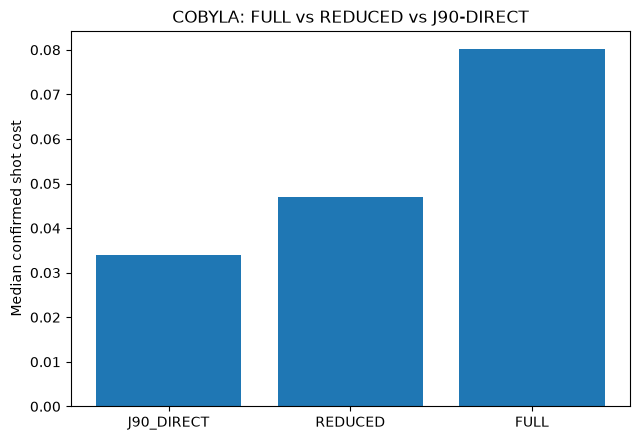

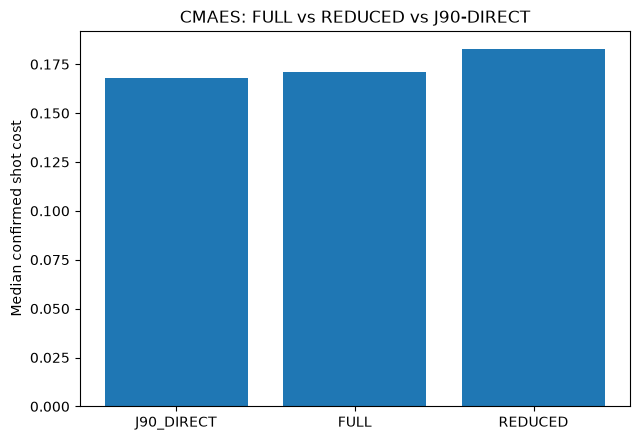

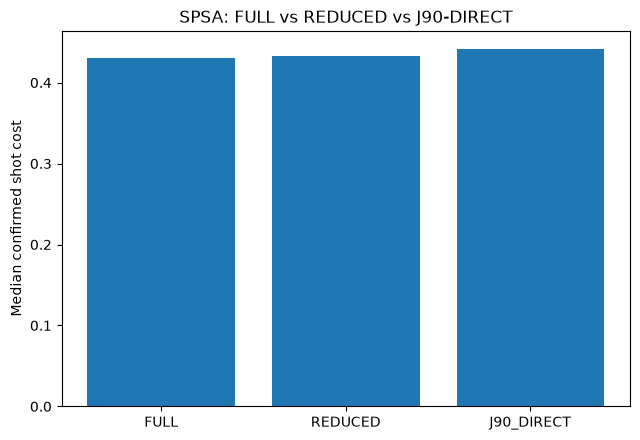

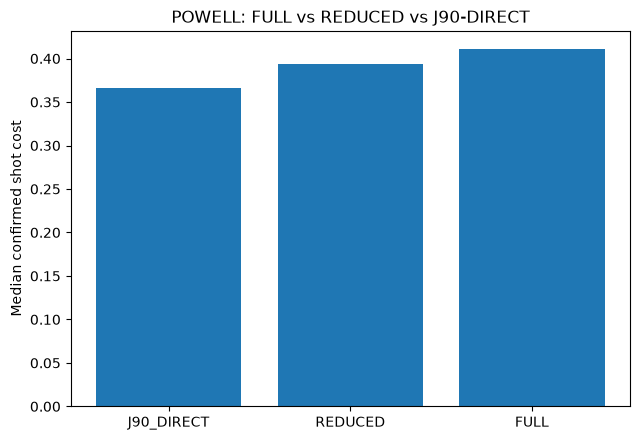

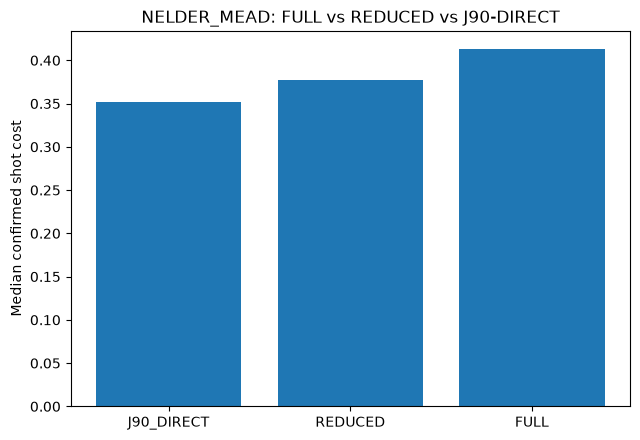

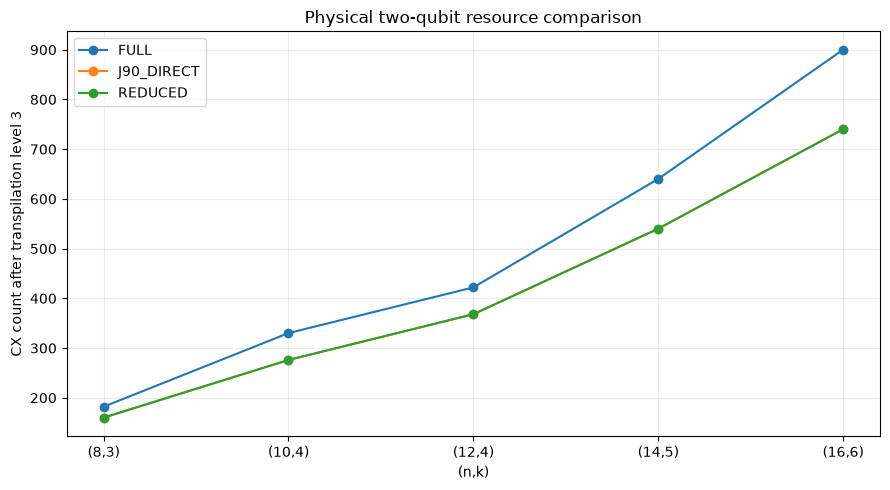

In [24]:
# ============================================================
# 20. Figures
# ============================================================
if len(SUMMARY):
    for optimizer in OPTIMIZERS:
        s = SUMMARY.loc[
            SUMMARY.optimizer.eq(optimizer)
        ].copy()

        fig,ax = plt.subplots(
            figsize=(6.5,4.5)
        )

        ax.bar(
            s.architecture,
            s.median_confirmed_cost,
        )

        ax.set_ylabel(
            "Median confirmed shot cost"
        )

        ax.set_title(
            f"{optimizer}: FULL vs REDUCED vs J90-DIRECT"
        )

        fig.tight_layout()

        fig.savefig(
            FIG_DIR/f"v31_19_{optimizer.lower()}_architectures.png",
            dpi=180,
            bbox_inches="tight",
        )

        plt.show()

# Resource figure at transpile level 3.
r = RESOURCE_AUDIT.loc[
    RESOURCE_AUDIT.transpile_level.astype(str).eq("3")
].copy()

if len(r):
    fig,ax = plt.subplots(
        figsize=(9,5)
    )

    for architecture,g in r.groupby("architecture"):
        ax.plot(
            [
                f"({int(a.n)},{int(a.k)})"
                for a in g.itertuples()
            ],
            g.cx,
            marker="o",
            label=architecture,
        )

    ax.set_ylabel("CX count after transpilation level 3")
    ax.set_xlabel("(n,k)")
    ax.set_title("Physical two-qubit resource comparison")
    ax.legend()
    ax.grid(alpha=0.25)

    fig.tight_layout()

    fig.savefig(
        FIG_DIR/"v31_19_cx_resources.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

# 21. Hard scientific contracts

O benchmark só pode ser interpretado se:

1. FULL tiver exatamente
   $k(n-k)+\binom{k}{2}$ parâmetros;
2. REDUCED tiver exatamente
   $k(n-k)$;
3. J90-DIRECT expuser exatamente
   $r_{90}$ parâmetros;
4. o $Q_{90}$ final retiver pelo menos 90% da energia positiva do cross-Gram médio;
5. todos os braços usarem o mesmo número de shots por batch;
6. todos consumirem exatamente o mesmo total de batches de otimização após padding;
7. todos receberem os mesmos 8 batches de confirmação;
8. cada caso TEST possuir todas as 15 combinações arquitetura × otimizador;
9. CAL e TEST forem disjuntos;
10. nenhuma métrica `exact_*` existir na tabela de resultados.

A estabilidade multi-seed de $Q_{90}$ é reportada como diagnóstico e não recebe um limiar arbitrário de aprovação.

In [25]:
# ============================================================
# 21A. Contracts
# ============================================================
CHECKS = []

def add_check(check,passed,detail=""):
    CHECKS.append({
        "check":check,
        "passed":bool(passed),
        "detail":str(detail),
    })

add_check(
    "FULL parameter count",
    bool(
        np.all(
            COUNT_AUDIT.full_parameters
            == COUNT_AUDIT.full_expected
        )
    ),
)

add_check(
    "REDUCED parameter count",
    bool(
        np.all(
            COUNT_AUDIT.reduced_parameters
            == COUNT_AUDIT.reduced_expected
        )
    ),
)

add_check(
    "J90-DIRECT exposes r90 parameters",
    bool(
        np.all(
            J90_COUNT.r90_expected
            == J90_COUNT.j90_circuit_parameters
        )
    ),
)


add_check(
    "corrected J90 physical equivalence",
    bool(
        (EQUIV_SUMMARY.max_infidelity <= 1e-12).all()
        and (EQUIV_SUMMARY.max_tvd <= 1e-12).all()
        and (EQUIV_SUMMARY.max_amp_error <= 1e-10).all()
    ),
    (
        f"max infidelity={EQUIV_SUMMARY.max_infidelity.max():.3e}; "
        f"max TVD={EQUIV_SUMMARY.max_tvd.max():.3e}; "
        f"max amp={EQUIV_SUMMARY.max_amp_error.max():.3e}"
    ),
)

add_check(
    "REDUCED and corrected J90 preserve canonical motif topology/order",
    bool(
        TOPOLOGY_AUDIT.same_motif_sequence.all()
        and TOPOLOGY_AUDIT.circuit_order_is_permutation.all()
        and TOPOLOGY_AUDIT.theta_index_is_permutation.all()
    ),
)

add_check(
    "final J90 retains >= 90% mean cross-Gram energy",
    bool(
        np.all(
            ARCH_SUMMARY.retained_energy_final
            >= J_ENERGY_TARGET-1e-12
        )
    ),
    (
        "min retained="
        f"{ARCH_SUMMARY.retained_energy_final.min():.6f}"
    ),
)

add_check(
    "CAL and TEST objectives disjoint",
    set(CAL_OBJECTIVES).isdisjoint(
        set(TEST_OBJECTIVES)
    ),
)

add_check(
    "same optimization batch cap",
    bool(
        np.all(
            TEST_RUNS.total_opt_batches
            == OPT_BATCH_BUDGET
        )
    ),
    (
        f"unique={sorted(TEST_RUNS.total_opt_batches.unique())}"
    ),
)

add_check(
    "no exact result columns",
    not any(
        str(c).lower().startswith("exact_")
        for c in TEST_RUNS.columns
    ),
    repr([
        c for c in TEST_RUNS.columns
        if str(c).lower().startswith("exact_")
    ]),
)

expected = set(
    f"{a}|{o}"
    for a,o in ARMS
)

coverage = (
    TEST_RUNS
    .assign(
        arm=lambda x:
            x.architecture
            +"|"
            +x.optimizer
    )
    .groupby(
        [
            "n","k",
            "objective_index",
            "noise_seed",
            "start",
        ]
    )
    .arm.apply(set)
)

add_check(
    "every TEST case contains all 15 arms",
    bool(
        all(
            s==expected
            for s in coverage
        )
    ),
    f"cases={len(coverage)}",
)

CONTRACT = pd.DataFrame(
    CHECKS
)

display(CONTRACT)

CONTRACT.to_csv(
    DATA_DIR/"v31_19_contract.csv",
    index=False,
)

failed = CONTRACT.loc[
    ~CONTRACT.passed
]

if len(failed):
    raise AssertionError(
        "V31.18 HARD CONTRACT FAILED:\n"
        + failed.to_string(index=False)
    )

,check,passed,detail
0,FULL parameter count,True,
1,REDUCED parameter count,True,
2,J90-DIRECT exposes r90 parameters,True,
3,corrected J90 physical equivalence,True,max infidelity=8.438e-15; max TVD=1.949e-15; m...
4,REDUCED and corrected J90 preserve canonical m...,True,
5,final J90 retains >= 90% mean cross-Gram energy,True,min retained=0.900377
6,CAL and TEST objectives disjoint,True,
7,same optimization batch cap,True,unique=[np.int64(112)]
8,no exact result columns,True,[]
9,every TEST case contains all 15 arms,True,cases=60


# 22. Interpretação permitida

## Se REDUCED $\simeq$ FULL em qualidade e usar menos gates

A conclusão será:

$$
\boxed{
\text{os motifs mortos podem ser removidos sem penalidade operacional mensurável.}
}
$$

Esse é um resultado de **redução estrutural física**.

## Se REDUCED melhorar FULL

Além da economia de circuito, poderemos afirmar que remover direções redundantes melhora a eficiência da busca sob orçamento finite-shot.

## Se J90-DIRECT melhorar REDUCED

A conclusão será:

$$
\boxed{
\text{a compressão geométrica local melhora a otimização para aquele algoritmo.}
}
$$

Não significa que $r_{90}$ seja uma dimensão exata ou universal.

## Se J90-DIRECT perder

Isso indicará que os 10% descartados contêm direções localmente fracas, mas operacionalmente úteis durante a trajetória de otimização.

---

A narrativa final pode então ser testada diretamente:

$$
\boxed{
N_{\rm nominal}
\rightarrow
N_{\rm structural}
\rightarrow
N_{\rm geometric}
}
$$

com

$$
N_{\rm nominal}
=
k(n-k)+\binom{k}{2},
$$

$$
N_{\rm structural}
=
k(n-k),
$$

e

$$
N_{\rm geometric}
=
r_{90}.
$$

O objetivo não é declarar uma dessas dimensões “a correta” em todos os sentidos, mas separar:

- redundância estrutural exata;
- parametrização física ativa;
- compressão geométrica local finite-shot.---

## V31.19 interpretation rule

The old V31.18 J90 performance must not be cited.

Only the corrected J90 results produced after the physical-equivalence hard gate are valid.